# Time-Series Modeling

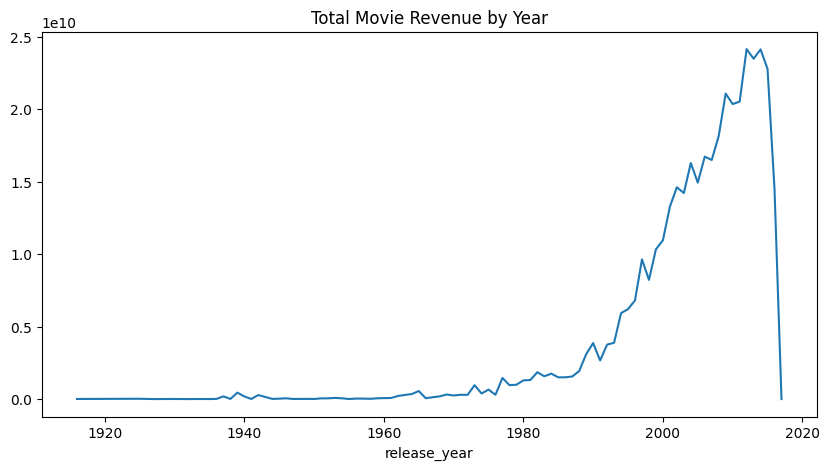

In [2]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

df = pd.read_csv('../data/movies.csv')

df["release_date"] = pd.to_datetime(df["release_date"])
df["release_month"] = df["release_date"].dt.month
df["release_year"] = df["release_date"].dt.year

revenue_by_year = df.groupby("release_year")["revenue"].sum()

revenue_by_year.plot(figsize=(10,5))
plt.title("Total Movie Revenue by Year")
plt.show()



### Checking if data is stationary ( mean, variance, and covariance are constant over time) or not

In [3]:
train = revenue_by_year.iloc[:-5]
test = revenue_by_year.iloc[-5:]
adf_result = adfuller(train)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: 5.911244304795797
p-value: 1.0


#### With a p-value > 0.05, we can conclude that our data is **non-stationary** (mean/variance changes over time). <br>
Total movie revenue by year most likely trends upward over time, so the mean is not constant.

In [4]:
model = SARIMAX(train, seasonal_order=(1,1,1, 4)) # The number 4 is for yearly data, whereas 12 is for monthly data
results = model.fit()
forecast = results.forecast(steps=5)
print(forecast)

85    2.486942e+10
86    2.574896e+10
87    2.583887e+10
88    2.736249e+10
89    2.875144e+10
Name: predicted_mean, dtype: float64


/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/stat

In [5]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print("MAE:", mae, "RMSE:", rmse)

MAE: 9547935844.39913 RMSE: 14192064991.889091


/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


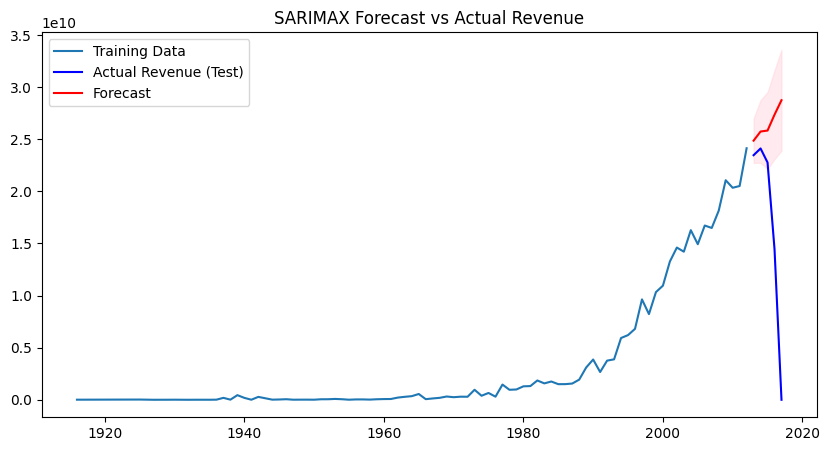

In [6]:
forecast_ci = results.get_forecast(steps=5).conf_int()
forecast_mean = results.get_forecast(steps=5).predicted_mean

forecast_index = test.index  # the last 5 years
forecast_mean.index = forecast_index
forecast_ci.index = forecast_index


plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Revenue (Test)", color="blue")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", color="red")
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color="pink", alpha=0.3)
plt.legend()
plt.title("SARIMAX Forecast vs Actual Revenue")
plt.show()


In [7]:
forecast_df = pd.DataFrame({
    "Year": forecast_mean.index,
    "Predicted_Revenue": forecast_mean.values,
    "Actual_Revenue": test.values,
})
print(forecast_df)

     Year  Predicted_Revenue  Actual_Revenue
0  2013.0       2.486942e+10     23474820496
1  2014.0       2.574896e+10     24120490589
2  2015.0       2.583887e+10     22775024221
3  2016.0       2.736249e+10     14461156948
4  2017.0       2.875144e+10               0


My model predicted that there would be continued revenue growth for movies from 2013-2017. We can see that in the actual results, there was a slight increase in revenue before a sharp decrease. This sharp decrease can be due to multiple factors:
- Changing audience preferences
- Macroeconomic conditions
- Competition from streaming and digital platforms
- Lower-budget films being released
- Model limitations

In [8]:
# df.to_csv('../data/time_series.csv', index=False)

ValueError: Length of values (5) does not match length of index (4809)